In [50]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [51]:
# Get the data from the file `backprop.csv`
df = pd.read_csv('backprop.csv')

# Get the predictor and response variables
x = df.x.values.reshape(-1,1)
y = df.y.values.reshape(-1,1)


In [52]:
# Initialize weights and biases (seed fixed at 310 for reproducibility)
np.random.seed(310)

# W stores [w1, w2] as a 2x1 array
W = np.array([np.random.randn(1, 1), np.random.randn(1, 1)]).reshape(-1,1)

# B stores [b1, b2] as a 2x1 array
B = np.array([np.random.randn(1, 1), np.random.randn(1, 1)]).reshape(-1,1)


### ⏸ What is the dimension of W?

#### A. 2x1
#### B. 1x2
#### C. 3x3
#### D. 3x1

In [53]:
### edTest(test_chow1) ###
# Submit an answer choice as a string below 
# (eg. if you choose option C, put 'C')
answer1 = 'A'


In [54]:
# Function to define the neural network
def neural_network(W, B, x):

    # W stores the two weights [w1, w2]
    # B stores the two biases [b1, b2]
    # x is the input to the neural network
    w1 = W[0].reshape(-1,1)
    w2 = W[1].reshape(-1,1)
    b1 = B[0].reshape(-1,1)
    b2 = B[1].reshape(-1,1)

    '''
    Compute h1, a1, h2, and y_pred.
    h1 is the affine transformation of the input: x*w1 + b1.
    a1 is the hidden activation: sin(h1).
    h2 is the second affine transformation: a1*w2 + b2.
    y_pred is the output activation: sin(h2).
    Return h1, a1, h2, and y_pred for gradient computations.
    '''

    # Fill each blank with the matching forward-pass expression.
    # Hint 1: h1 uses x, w1, and b1.
    h1 = x*w1 + b1
    # Hint 2: a1 is the sine activation of h1.
    a1 = np.sin(h1)
    # Hint 3: h2 uses a1, w2, and b2.
    h2 = a1*w2 + b2
    # Hint 4: y_pred is the sine activation of h2.
    y_pred = np.sin(h2)
    
    # Return all intermediates needed for derivatives.
    return h1, a1, h2, y_pred

## True function vs neural network predictions
Here we plot our neural network predictions (with random initializations) along with the true function

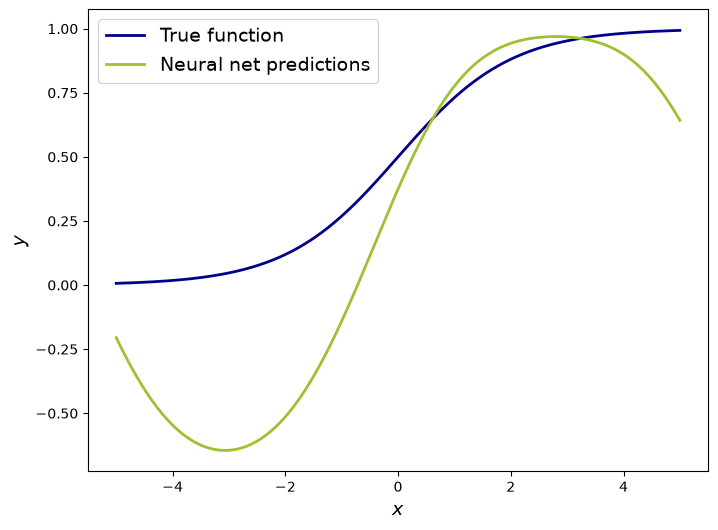

In [55]:
fig,ax = plt.subplots(1,1,figsize=(8,6))

# Plot the true x and y values
ax.plot(x,y,label = 'True function',color='darkblue',linewidth=2)

# Plot the x values with the network predictions
h1, a1, h2, y_pred = neural_network(W, B, x)
ax.plot(x,y_pred,label = 'Neural net predictions',color='#9FC131FF',linewidth=2)

# Set the x and y labels
ax.set_xlabel('$x$',fontsize=14)
ax.set_ylabel('$y$',fontsize=14)
ax.legend(fontsize=14);


In [56]:
### edTest(test_nn_mse) ###

# You can use mean_squared_error to find MSE against the true function.
# Hint: call neural_network(W, B, x) and unpack 4 outputs.
h1, a1, h2, y_initial = neural_network(W, B, x)
# Hint: mean_squared_error takes (true_values, predicted_values).
mse_initial = mean_squared_error(y, y_initial)
print(f'The MSE of the neural network predictions wrt true function is {mse_initial:.4f}')


The MSE of the neural network predictions wrt true function is 0.1472


# Single update

### ⏸ What is $\frac{\partial L}{\partial w_2}$ from the options below: 

#### A. $\frac{1}{n}\sum_i^n2\left(y_{pred}\ -y\right)\cos\left(h_2\right)\sin\left(h_1\right)$
#### B. $\frac{1}{n}\sum_i^n2\left(y-y_{pred}\ \right)\cos\left(a_2\right)\sin\left(a_1\right)$
#### C. $\frac{1}{n}\sum_i^n2\left(y-y_{pred}\ \right)\sin\left(h_2\right)\sin\left(h_1\right)$
#### D. $\frac{1}{n}\sum_i^n2\left(y_{pred}\ -y\right)\cos\left(a_2\right)\sin\left(a_1\right)$

In [57]:
### edTest(test_chow2) ###
# Submit an answer choice as a string below 
# (eg. if you choose option C, put 'C')
answer2 = 'A'


In [58]:
# Here we will update the parameters only once

# Get network intermediates and predictions.
# Hint: call neural_network(W, B, x) and unpack all returned values.
h1, a1, h2, y_pred = neural_network(W, B, x)

# Gradients for the second layer parameters (w2, b2).
# Hint: dldw2 uses 2*(y_pred - y), cos(h2), and a1.
dh2 = 2 * (y_pred - y) * np.cos(h2)
dldw2 = np.mean(dh2*a1)
# Hint: dldb2 is like dldw2 but without multiplying by a1.
dldb2 = np.mean(dh2)

# Gradients for the first layer parameters (w1, b1).
# Hint: both use W[1] and cos(h1); only dldw1 also multiplies by x.\
dh1 = 2 * (y_pred - y) * np.cos(h1)
dh1 = dh1 * W[1]
dldw1 = np.mean(dh1*x)
dldb1 = np.mean(dh1)


In [59]:
# In the update step, apply gradient descent to weights and biases.
# Here we take a learning rate of 1.
lr = 1
W[0] = W[0] - lr * dldw1
W[1] = W[1] - lr * dldw2
B[0] = B[0] - lr * dldb1
B[1] = B[1] - lr * dldb2

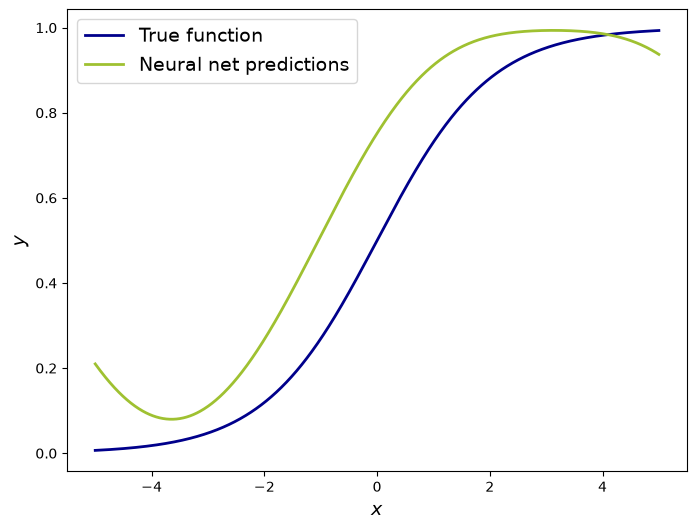

In [60]:
fig,ax = plt.subplots(1,1,figsize=(8,6))

# Plot the true x and y values
ax.plot(x,y,label = 'True function',color='darkblue',linewidth=2)

# Plot the x values with the network predictions
h1, a1, h2, y_pred = neural_network(W, B, x)
ax.plot(x,y_pred,label = 'Neural net predictions',color='#9FC131FF',linewidth=2)

# Set the x and y labels
ax.set_xlabel('$x$',fontsize=14)
ax.set_ylabel('$y$',fontsize=14)
ax.legend(fontsize=14);

In [61]:
### edTest(test_one_update_mse) ###

# Compute the new MSE after one update and print it
h1, a1, h2, y_pred = neural_network(W, B, x)

# Hint: compare y (true) against y_pred (prediction).
mse_update = np.mean((y - y_pred)**2)
print(f'The MSE of the new neural network predictions with true function is {mse_update:.4f} as compared to {mse_initial:.4f} from before ')

The MSE of the new neural network predictions with true function is 0.0212 as compared to 0.1472 from before 


# Several updates

In principle, only a single update will never be sufficient to improve model predictions.
In the below segment, we use the method from above, and update the weight 300 times before plotting predictions. This part is done for you.


In [62]:
# Reinitialize weights and biases to start again
np.random.seed(310)
W = np.array([np.random.randn(1, 1), np.random.randn(1, 1)]).reshape(-1,1)
B = np.array([np.random.randn(1, 1), np.random.randn(1, 1)]).reshape(-1,1)

In [63]:
# Unlike the previous step, set a smaller learning rate
lr = 0.01
for i in range(300):
    h1, a1, h2, y_pred = neural_network(W, B, x)

    # Gradients from mean squared error loss
    dldw2 = np.mean(2 * (y_pred - y) * np.cos(h2) * a1)
    dldb2 = np.mean(2 * (y_pred - y) * np.cos(h2))
    dldw1 = np.mean(2 * (y_pred - y) * np.cos(h2) * W[1] * np.cos(h1) * x)
    dldb1 = np.mean(2 * (y_pred - y) * np.cos(h2) * W[1] * np.cos(h1))
    
    W[0] = W[0] - lr * dldw1
    W[1] = W[1] - lr * dldw2
    B[0] = B[0] - lr * dldb1
    B[1] = B[1] - lr * dldb2

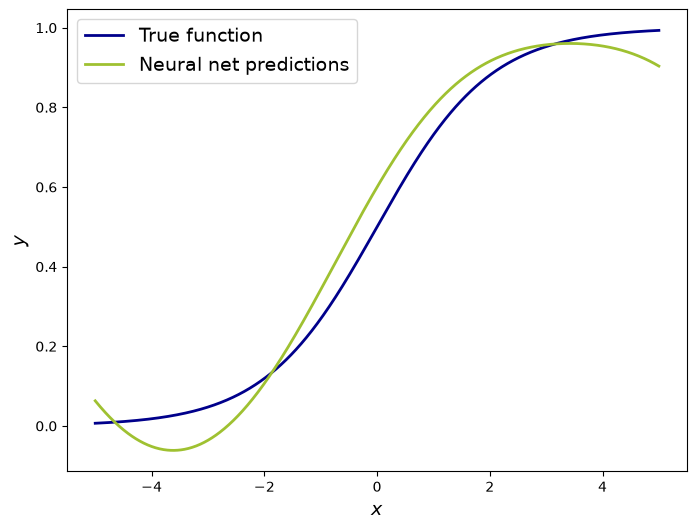

In [64]:
fig,ax = plt.subplots(1,1,figsize=(8,6))

# Plot the true x and y values
ax.plot(x,y,label = 'True function',color='darkblue',linewidth=2)

# Plot the x values with the network predictions
h1, a1, h2, y_pred = neural_network(W, B, x)
ax.plot(x,y_pred,label = 'Neural net predictions',color='#9FC131FF',linewidth=2)

# Set the x and y labels
ax.set_xlabel('$x$',fontsize=14)
ax.set_ylabel('$y$',fontsize=14)
ax.legend(fontsize=14);

In [65]:
### edTest(test_mse) ###

# We again compute the MSE and compare it with the original predictions
h1, a1, h2, y_pred = neural_network(W,B,x)

mse_final = np.mean((y - y_pred)**2)

print(f'The final MSE is {mse_final:.4f} as compared to {mse_initial:.4f} from before ')

The final MSE is 0.0037 as compared to 0.1472 from before 
